<a href="https://colab.research.google.com/github/Sk-Naqeeb/MNIST_model_NN/blob/main/mnist_model_nn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

In [ ]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)
# (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


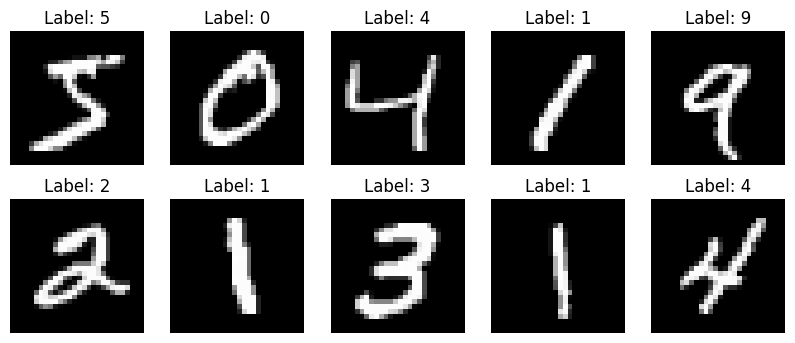

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")
plt.show()

In [ ]:
print(np.bincount(y_train))  # check class balance

X_train = X_train.astype("float32") / 255.0   # scale to [0, 1]
X_test  = X_test.astype("float32") / 255.0

[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]


In [ ]:
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10)
])

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9228 - loss: 0.2594 - val_accuracy: 0.9632 - val_loss: 0.1227
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9677 - loss: 0.1065 - val_accuracy: 0.9720 - val_loss: 0.0978
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9765 - loss: 0.0743 - val_accuracy: 0.9762 - val_loss: 0.0796
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9821 - loss: 0.0559 - val_accuracy: 0.9768 - val_loss: 0.0855
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9858 - loss: 0.0439 - val_accuracy: 0.9753 - val_loss: 0.0930
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.9775 - val_loss: 0.0897
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9906 - loss: 0.0282 - val_accuracy: 0.9752 - val_loss: 0.1073
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9920 - loss: 0.0252

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9769 - loss: 0.1049
Test accuracy: 0.9769


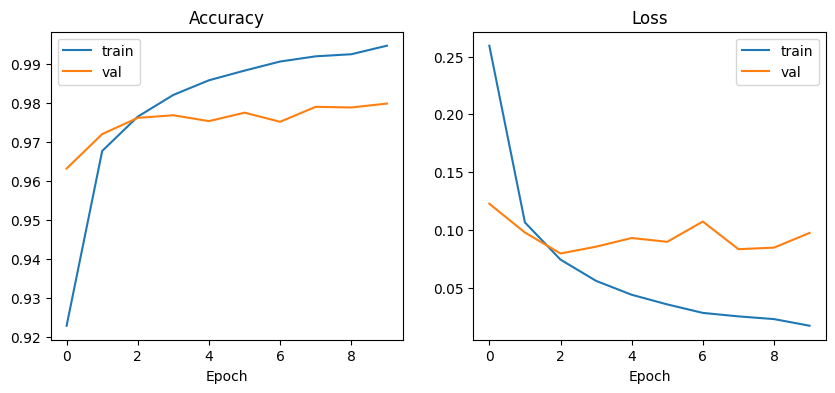

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


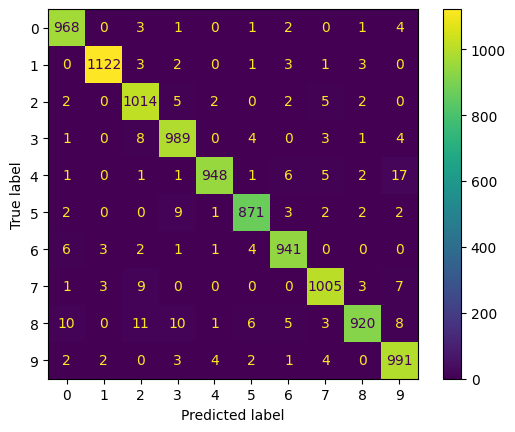

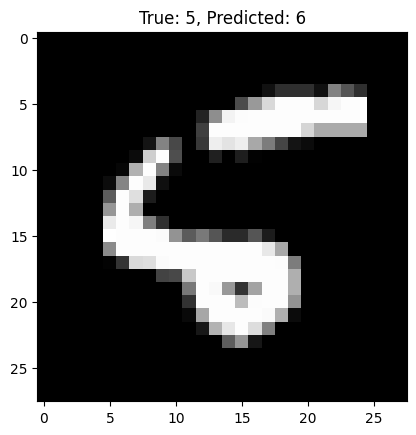

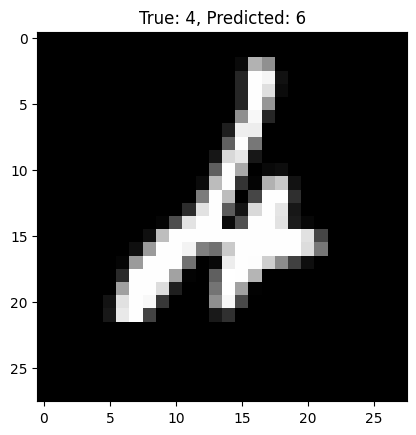

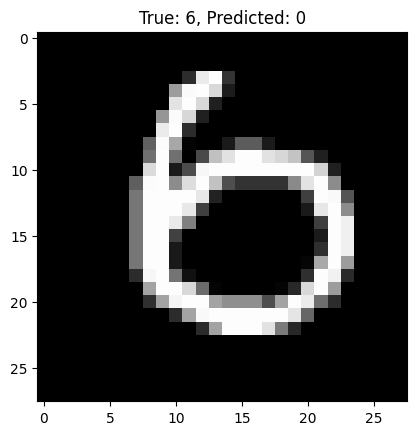

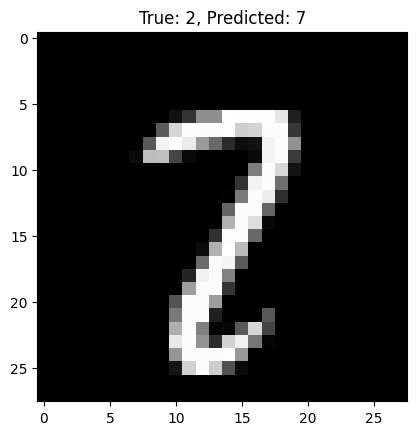

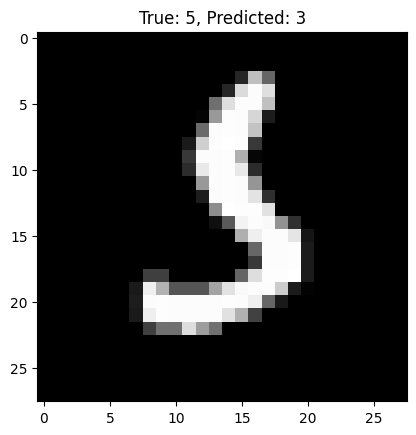

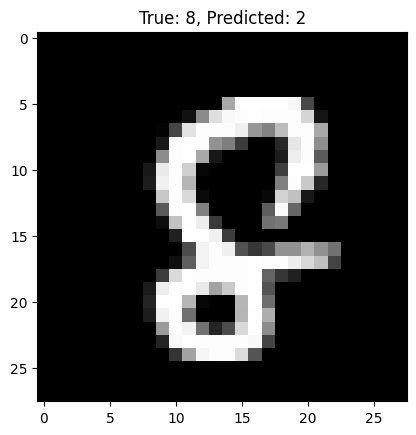

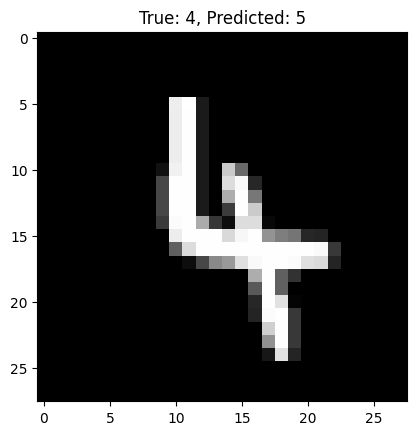

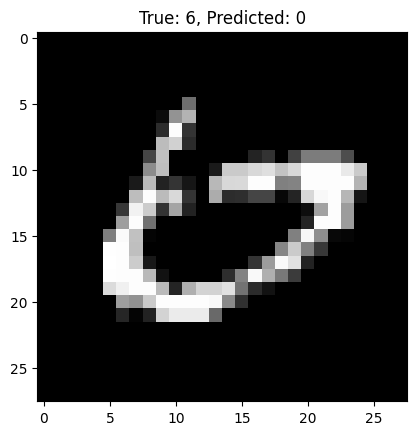

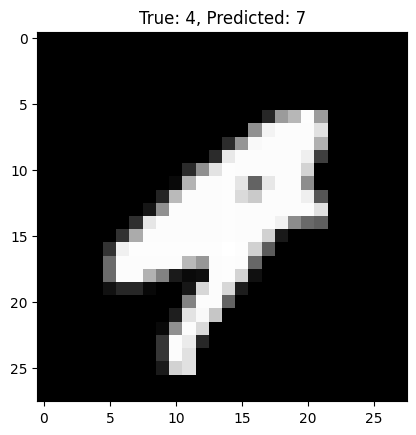

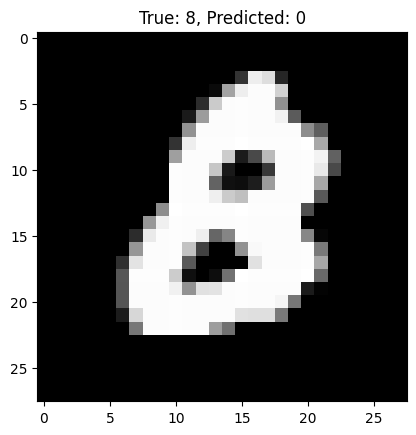

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

logits = model.predict(X_test)
probs = tf.nn.softmax(logits).numpy()
y_pred = np.argmax(probs, axis=1)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()
plt.show()

wrong = np.where(y_pred != y_test)[0][:10]
for i in wrong:
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]}, Predicted: {y_pred[i]}")
    plt.show()

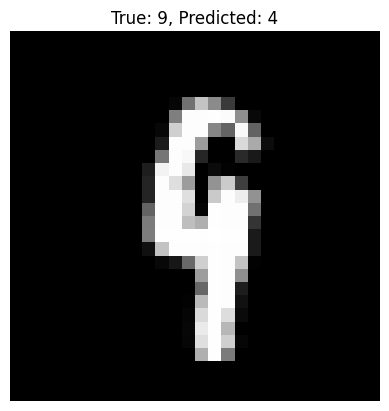

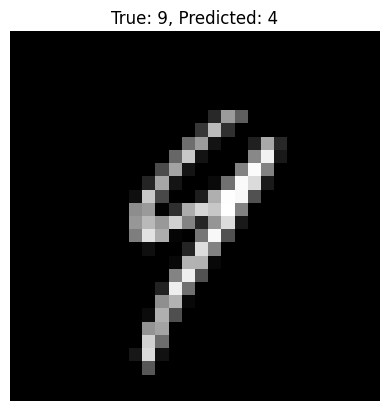

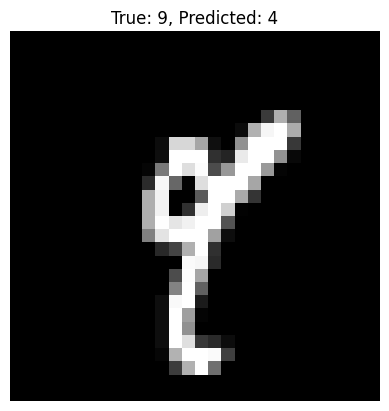

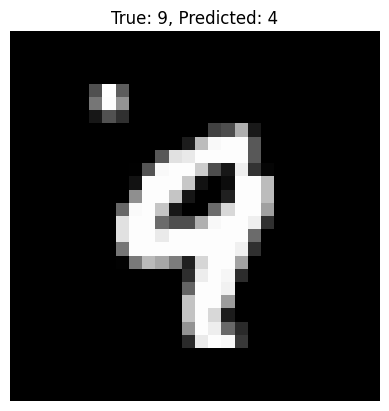

In [ ]:
wrong = np.where(y_pred != y_test)[0]
# specifically look at 9s predicted as 4s
nine_as_four = wrong[(y_test[wrong] == 9) & (y_pred[wrong] == 4)]
for i in nine_as_four[:6]:
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"True: 9, Predicted: 4")
    plt.axis("off")
    plt.show()

In [ ]:
model2 = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10)
])

model2.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history2 = model2.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)
print(model2.evaluate(X_test, y_test))

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.8937 - loss: 0.3550 - val_accuracy: 0.9618 - val_loss: 0.1333
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9485 - loss: 0.1712 - val_accuracy: 0.9727 - val_loss: 0.0938
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9598 - loss: 0.1339 - val_accuracy: 0.9760 - val_loss: 0.0796
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9658 - loss: 0.1107 - val_accuracy: 0.9783 - val_loss: 0.0799
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9709 - loss: 0.0941 - val_accuracy: 0.9770 - val_loss: 0.0832
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9727 - loss: 0.0865 - val_accuracy: 0.9790 - val_loss: 0.0763
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9748 - loss: 0.0808 - val_accuracy: 0.9783 - val_loss: 0.0773
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9769 - loss: 0.0732 

In [ ]:
cnn = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Reshape((28, 28, 1)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10)
])

cnn.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

history_cnn = cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

cnn.evaluate(X_test, y_test)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9358 - loss: 0.2088 - val_accuracy: 0.9855 - val_loss: 0.0516
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9793 - loss: 0.0664 - val_accuracy: 0.9863 - val_loss: 0.0443
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.9851 - loss: 0.0475 - val_accuracy: 0.9888 - val_loss: 0.0416
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9876 - loss: 0.0390 - val_accuracy: 0.9882 - val_loss: 0.0403
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9896 - loss: 0.0320 - val_accuracy: 0.9910 - val_loss: 0.0348
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9911 - loss: 0.0274 - val_accuracy: 0.9913 - val_loss: 0.0323
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9917 - loss: 0.0241 - val_accuracy: 0.9915 - val_loss: 0.0296
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9929 - loss: 0.0210 - 

[0.02878914773464203, 0.9901000261306763]

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step


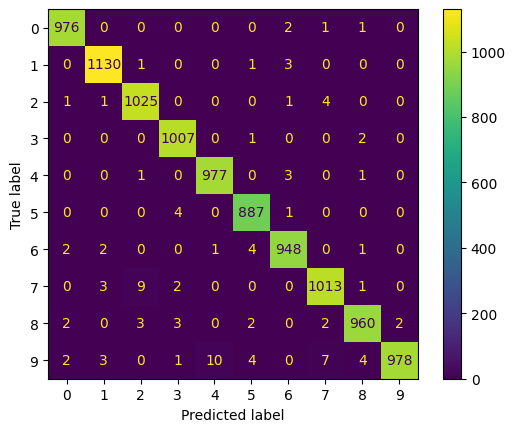

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
logits_cnn = cnn.predict(X_test)
probs_cnn = tf.nn.softmax(logits_cnn).numpy()
y_pred_cnn = np.argmax(probs_cnn, axis=1)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn)).plot()
plt.show()

Total errors: 99


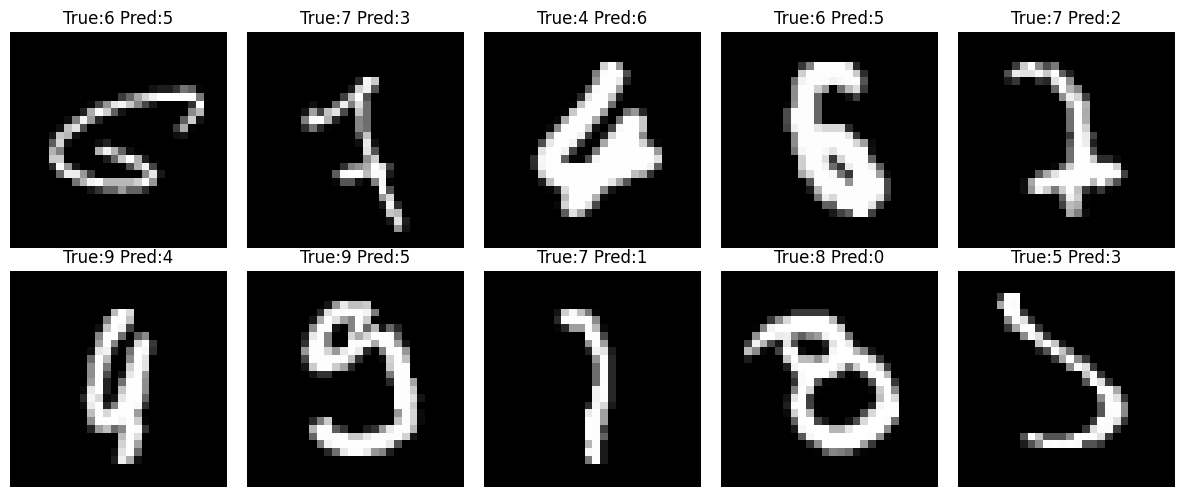

In [ ]:
wrong_cnn = np.where(y_pred_cnn != y_test)[0]
print(f"Total errors: {len(wrong_cnn)}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, idx in enumerate(wrong_cnn[10:20]):
    axes.flat[i].imshow(X_test[idx], cmap="gray")
    axes.flat[i].set_title(f"True:{y_test[idx]} Pred:{y_pred_cnn[idx]}")
    axes.flat[i].axis("off")
plt.tight_layout()
plt.show()